In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [42]:
df = pd.read_csv("../dataset/cyber_attack_dataset.csv")
df.head()

,duration,src_bytes,dst_bytes,packet_count,protocol,failed_logins,attack_type
0,1,8605,418,631,TCP,0,DDoS
1,1,499,148,131,UDP,0,PortScan
2,10,370,160,105,UDP,0,PortScan
3,2,5138,320,666,TCP,0,DDoS
4,36,524,467,58,UDP,10,BruteForce


In [3]:
df.tail()

,duration,src_bytes,dst_bytes,packet_count,protocol,failed_logins,attack_type
99995,10,380,41,143,TCP,0,PortScan
99996,2,153,146,85,TCP,0,PortScan
99997,37,161,114,61,UDP,10,BruteForce
99998,4,142,69,73,TCP,0,PortScan
99999,2,8514,445,681,TCP,0,DDoS


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   duration       100000 non-null  int64
 1   src_bytes      100000 non-null  int64
 2   dst_bytes      100000 non-null  int64
 3   packet_count   100000 non-null  int64
 4   protocol       100000 non-null  str  
 5   failed_logins  100000 non-null  int64
 6   attack_type    100000 non-null  str  
dtypes: int64(5), str(2)
memory usage: 5.3 MB


In [5]:
df.shape

(100000, 7)

In [6]:
df.isnull().sum()

duration         0
src_bytes        0
dst_bytes        0
packet_count     0
protocol         0
failed_logins    0
attack_type      0
dtype: int64

In [7]:
df.describe()

,duration,src_bytes,dst_bytes,packet_count,failed_logins
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000
mean,16.462720,2219.62870,426.171030,202.550770,1.630520
std,15.632207,2751.14241,466.528205,249.729802,3.045577
min,1.000000,50.00000,20.000000,5.000000,0.000000
25%,4.000000,341.00000,131.000000,37.000000,0.000000
50%,10.000000,781.00000,256.000000,87.000000,0.000000
75%,28.000000,3024.00000,458.000000,257.000000,3.000000
max,60.000000,10000.00000,2000.000000,1000.000000,10.000000


Max = 1000 packets (DDoS attack!)

Median = 87 packets (Normal or PortScan)

Min = 5 packets (Normal traffic)

IF LOGIN TIME IS 0, IT IS BRUTE-FORCE ATTACK

In [8]:
df.nunique()

duration           60
src_bytes        9739
dst_bytes        1981
packet_count      996
protocol            2
failed_logins       9
attack_type         4
dtype: int64

In [9]:
df.skew(numeric_only=True)

duration         0.981925
src_bytes        1.404002
dst_bytes        1.841663
packet_count     1.675901
failed_logins    1.597554
dtype: float64

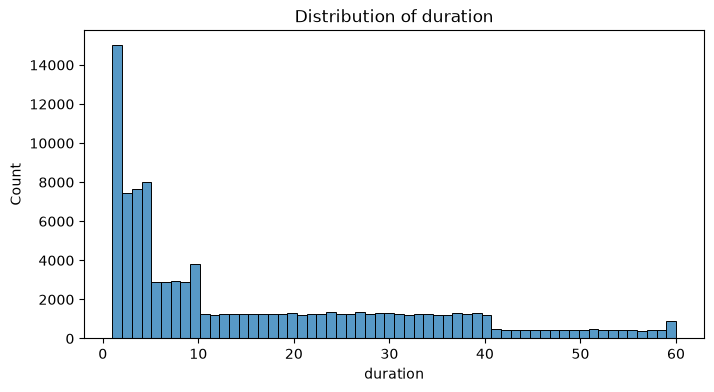

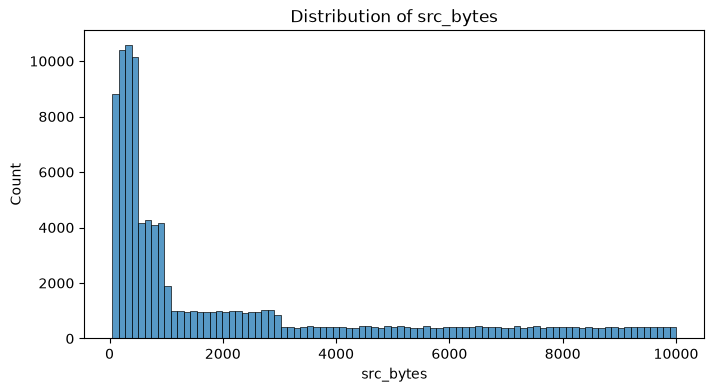

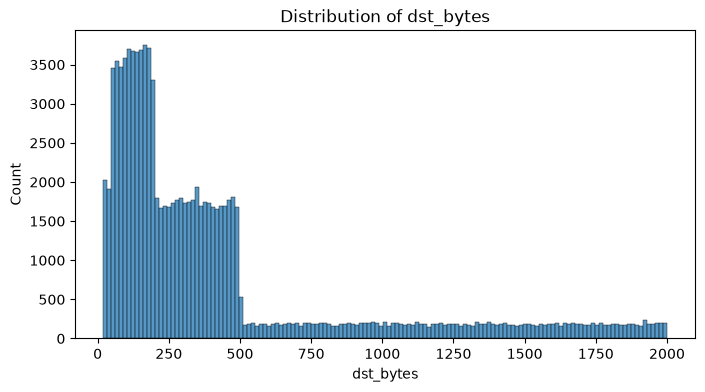

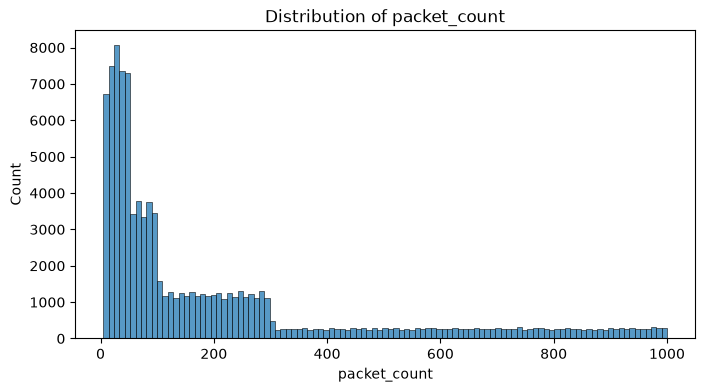

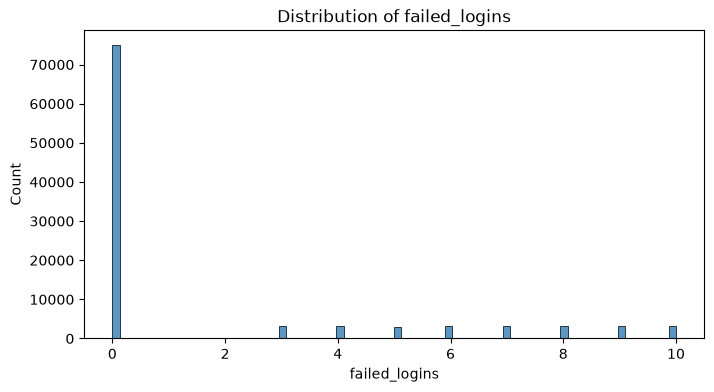

In [10]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
for i in numeric_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(df[i])
    plt.title(f"Distribution of {i}")
    plt.show()

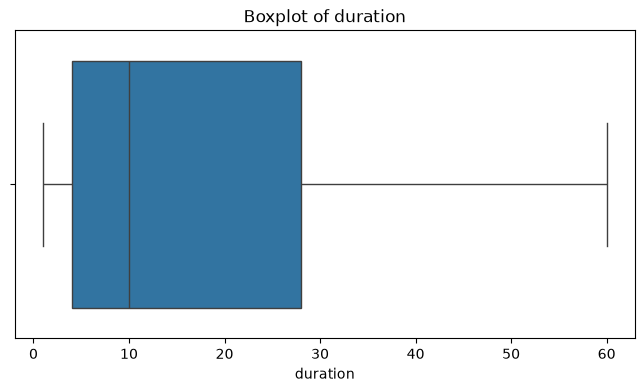

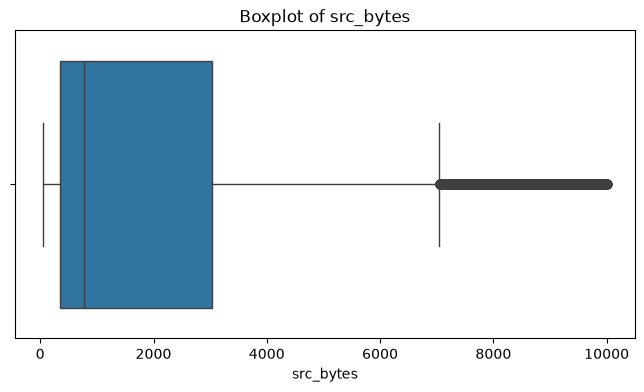

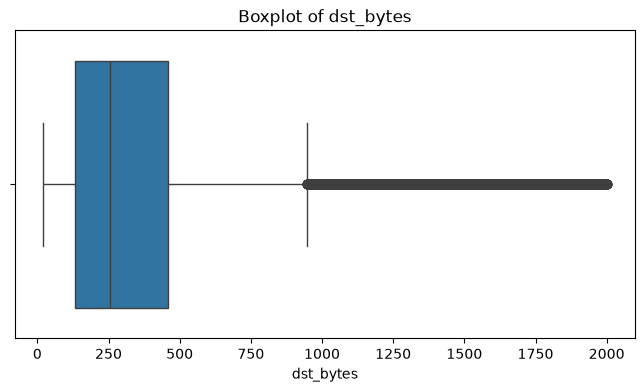

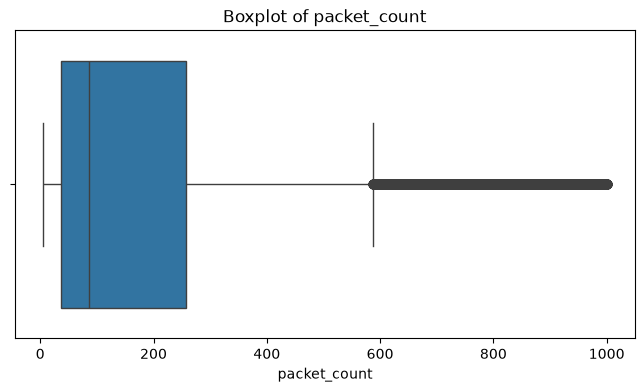

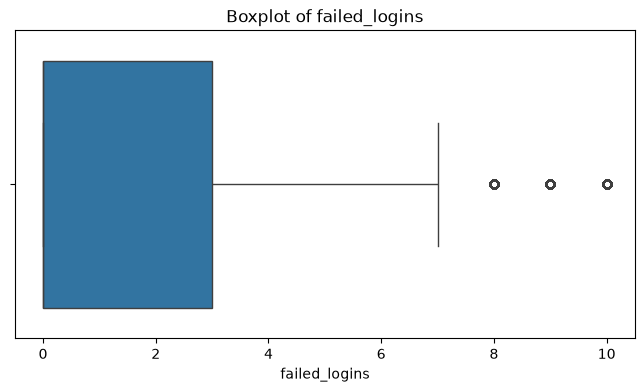

In [11]:
for i in numeric_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[i])
    plt.title(f"Boxplot of {i}")
    plt.show()

In [12]:
q1 = df[numeric_cols].quantile(0.25)
q3 = df[numeric_cols].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outliers = (df[numeric_cols] < lower_bound) | (df[numeric_cols] > upper_bound)
print(outliers.sum())

duration             0
src_bytes        10547
dst_bytes        13746
packet_count     11556
failed_logins     9446
dtype: int64


In [13]:
#z-score
from scipy import stats
z_scores = np.abs(stats.zscore(df[numeric_cols]))
outliers_z = (z_scores > 3).sum()
print(outliers_z)

3758


In [14]:
df['src_bytes'] = np.log1p(df['src_bytes'])
df['dst_bytes'] = np.log1p(df['dst_bytes'])
df['packet_count'] = np.log1p(df['packet_count'])
df['failed_logins'] = np.log1p(df['failed_logins'])

In [15]:
#z-score
from scipy import stats
z_scores = np.abs(stats.zscore(df[numeric_cols]))
outliers_z = (z_scores > 3).sum()
print(outliers_z)

0


In [16]:
q1 = df[numeric_cols].quantile(0.25)
q3 = df[numeric_cols].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outliers = (df[numeric_cols] < lower_bound) | (df[numeric_cols] > upper_bound)
print(outliers.sum())

duration         0
src_bytes        0
dst_bytes        0
packet_count     0
failed_logins    0
dtype: int64


In [17]:
df

,duration,src_bytes,dst_bytes,packet_count,protocol,failed_logins,attack_type
0,1,9.060215,6.037871,6.448889,TCP,0.000000,DDoS
1,1,6.214608,5.003946,4.882802,UDP,0.000000,PortScan
2,10,5.916202,5.081404,4.663439,UDP,0.000000,PortScan
3,2,8.544614,5.771441,6.502790,TCP,0.000000,DDoS
4,36,6.263398,6.148468,4.077537,UDP,2.397895,BruteForce
...,...,...,...,...,...,...,...
99995,10,5.942799,3.737670,4.969813,TCP,0.000000,PortScan
99996,2,5.036953,4.990433,4.454347,TCP,0.000000,PortScan
99997,37,5.087596,4.744932,4.127134,UDP,2.397895,BruteForce
99998,4,4.962845,4.248495,4.304065,TCP,0.000000,PortScan


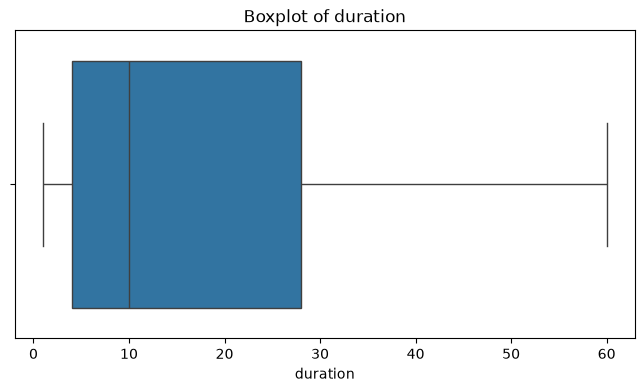

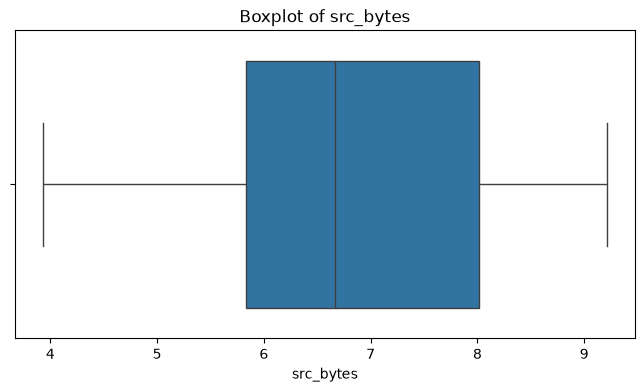

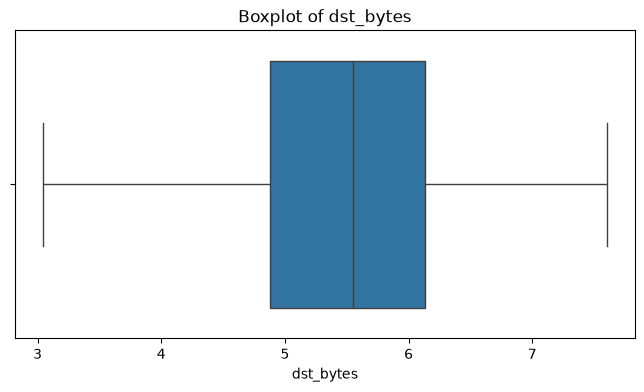

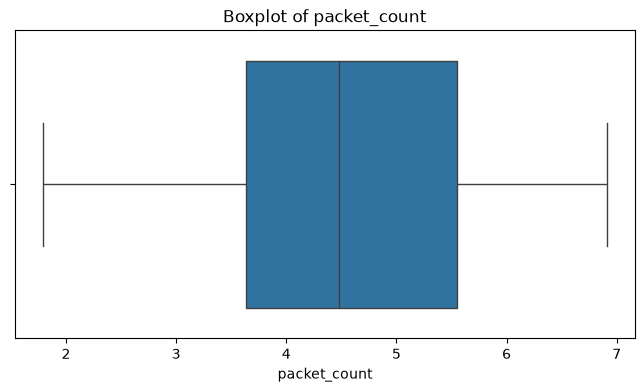

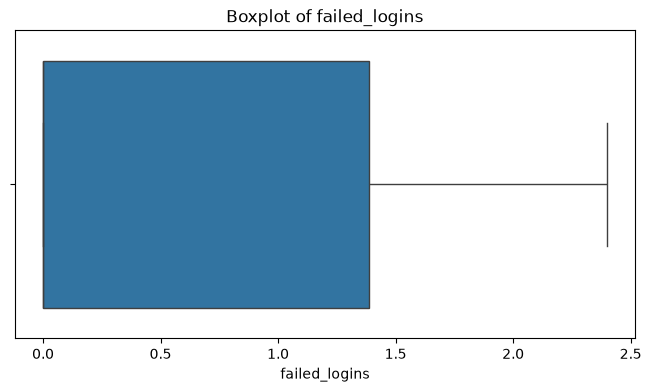

In [23]:
for i in numeric_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[i])
    plt.title(f"Boxplot of {i}")
    plt.show()

In [41]:
for attack in df['attack_type'].unique():
    count = (df['attack_type'] == attack).sum()
    print(f"{attack}: {count}")

DDoS: 25077
PortScan: 25008
BruteForce: 25039
Normal: 24876


### Target Variable is balanced

attack_type
DDoS          25077
BruteForce    25039
PortScan      25008
Normal        24876
Name: count, dtype: int64

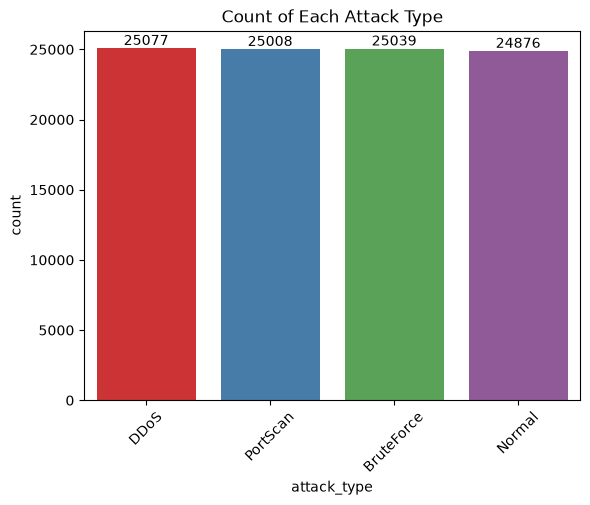

In [52]:
ax = sns.countplot(x='attack_type', data=df, palette='Set1', hue='attack_type')
for container in ax.containers:
    ax.bar_label(container)
plt.title("Count of Each Attack Type")
plt.xticks(rotation=45)
plt.show()

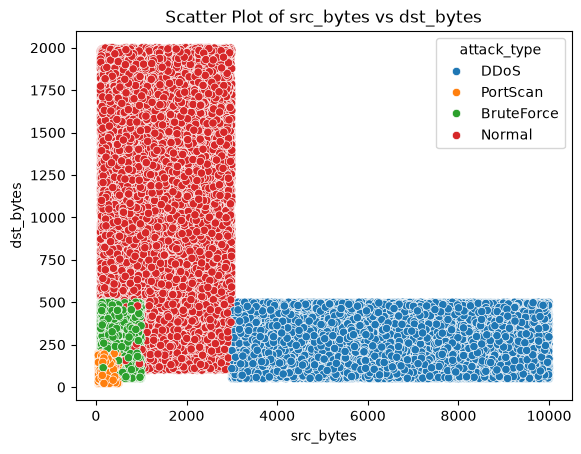

In [53]:
sns.scatterplot(x='src_bytes', y='dst_bytes', hue='attack_type',data=df)
plt.title("Scatter Plot of src_bytes vs dst_bytes")
plt.show()


In [55]:
df.corr(numeric_only=True)

,duration,src_bytes,dst_bytes,packet_count,failed_logins
duration,1.000000,-0.357621,0.484247,-0.541066,0.293586
src_bytes,-0.357621,1.000000,-0.038516,0.698661,-0.325359
dst_bytes,0.484247,-0.038516,1.000000,-0.279961,-0.175321
packet_count,-0.541066,0.698661,-0.279961,1.000000,-0.316262
failed_logins,0.293586,-0.325359,-0.175321,-0.316262,1.000000


In [56]:
df.to_csv("../dataset/cleaned_dataset/cyber_attack_dataset_cleaned.csv", index=False)